In [1]:
import os
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BASE = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

In [4]:
with open("dataset_split.pkl", "rb") as f:
    split = pickle.load(f)

train_files = split["train"]
val_files = split["val"]
test_files = split["test"]

print(len(train_files), len(val_files), len(test_files))

35 7 8


In [5]:
def convert_av_to_mask(av):
    mask = np.zeros(av.shape[:2], dtype=np.uint8)

    red = np.all(av == [255, 0, 0], axis=-1)
    blue = np.all(av == [0, 0, 255], axis=-1)
    green = np.all(av == [0, 255, 0], axis=-1)

    mask[red] = 1
    mask[blue] = 1
    mask[green] = 1

    return mask

In [6]:
class VesselDataset(Dataset):
    def __init__(self, file_list, base_path, resize=(1152, 768)):
        self.file_list = file_list
        self.base_path = base_path
        self.resize = resize

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        image_path = os.path.join(self.base_path, "images", filename)
        av_path = os.path.join(self.base_path, "av", filename)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        av = cv2.imread(av_path)
        av = cv2.cvtColor(av, cv2.COLOR_BGR2RGB)

        mask = convert_av_to_mask(av)

        image = cv2.resize(image, self.resize)
        mask = cv2.resize(mask, self.resize, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [7]:
train_dataset = VesselDataset(train_files, BASE)
val_dataset = VesselDataset(val_files, BASE)
test_dataset = VesselDataset(test_files, BASE)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

In [8]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)
print(torch.unique(masks))

torch.Size([4, 3, 768, 1152])
torch.Size([4, 768, 1152])
tensor([0, 1])


In [9]:
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=2
).to(device)

In [10]:
class_weights = torch.tensor([1.0, 10.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [12]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

In [13]:
def compute_metrics(preds, targets):
    preds = torch.argmax(preds, dim=1)

    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = ((preds == 1) & (targets == 1)).sum().item()
    TN = ((preds == 0) & (targets == 0)).sum().item()
    FP = ((preds == 1) & (targets == 0)).sum().item()
    FN = ((preds == 0) & (targets == 1)).sum().item()

    dice = (2 * TP) / (2 * TP + FP + FN + 1e-6)
    sensitivity = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)

    return dice, sensitivity, specificity, accuracy

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    total_dice = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        dice, _, _, _ = compute_metrics(outputs, masks)

        total_loss += loss.item()
        total_dice += dice

    return total_loss / len(loader), total_dice / len(loader)

In [15]:
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    total_dice = 0
    total_sen = 0
    total_spec = 0
    total_acc = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            dice, sen, spec, acc = compute_metrics(outputs, masks)

            total_loss += loss.item()
            total_dice += dice
            total_sen += sen
            total_spec += spec
            total_acc += acc

    n = len(loader)

    return (
        total_loss / n,
        total_dice / n,
        total_sen / n,
        total_spec / n,
        total_acc / n
    )

In [16]:
best_val_dice = 0
EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_dice, val_sen, val_spec, val_acc = validate(
        model, val_loader, criterion, device
    )

    scheduler.step()

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "baseline_best.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Dice: {val_dice:.4f}")
    print(f"Val Sensitivity: {val_sen:.4f}")
    print(f"Val Specificity: {val_spec:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print("-"*50)

Epoch 1/20
Train Loss: 0.7088 | Train Dice: 0.1590
Val Loss: 1.0355
Val Dice: 0.1187
Val Sensitivity: 0.9972
Val Specificity: 0.0055
Val Accuracy: 0.0679
--------------------------------------------------
Epoch 2/20
Train Loss: 0.5540 | Train Dice: 0.2513
Val Loss: 0.6315
Val Dice: 0.1883
Val Sensitivity: 0.6090
Val Specificity: 0.6690
Val Accuracy: 0.6652
--------------------------------------------------
Epoch 3/20
Train Loss: 0.4757 | Train Dice: 0.3212
Val Loss: 0.6387
Val Dice: 0.1843
Val Sensitivity: 0.3780
Val Specificity: 0.8162
Val Accuracy: 0.7888
--------------------------------------------------
Epoch 4/20
Train Loss: 0.4221 | Train Dice: 0.3937
Val Loss: 0.6274
Val Dice: 0.3259
Val Sensitivity: 0.2805
Val Specificity: 0.9706
Val Accuracy: 0.9274
--------------------------------------------------
Epoch 5/20
Train Loss: 0.3816 | Train Dice: 0.4665
Val Loss: 0.6188
Val Dice: 0.3262
Val Sensitivity: 0.2395
Val Specificity: 0.9849
Val Accuracy: 0.9381
--------------------------

In [17]:
model.load_state_dict(torch.load("baseline_best.pth"))

test_loss, test_dice, test_sen, test_spec, test_acc = validate(
    model, test_loader, criterion, device
)

print("FINAL TEST METRICS")
print(f"Loss: {test_loss:.4f}")
print(f"Dice: {test_dice:.4f}")
print(f"Sensitivity: {test_sen:.4f}")
print(f"Specificity: {test_spec:.4f}")
print(f"Accuracy: {test_acc:.4f}")

FINAL TEST METRICS
Loss: 0.4126
Dice: 0.6426
Sensitivity: 0.5928
Specificity: 0.9831
Accuracy: 0.9586


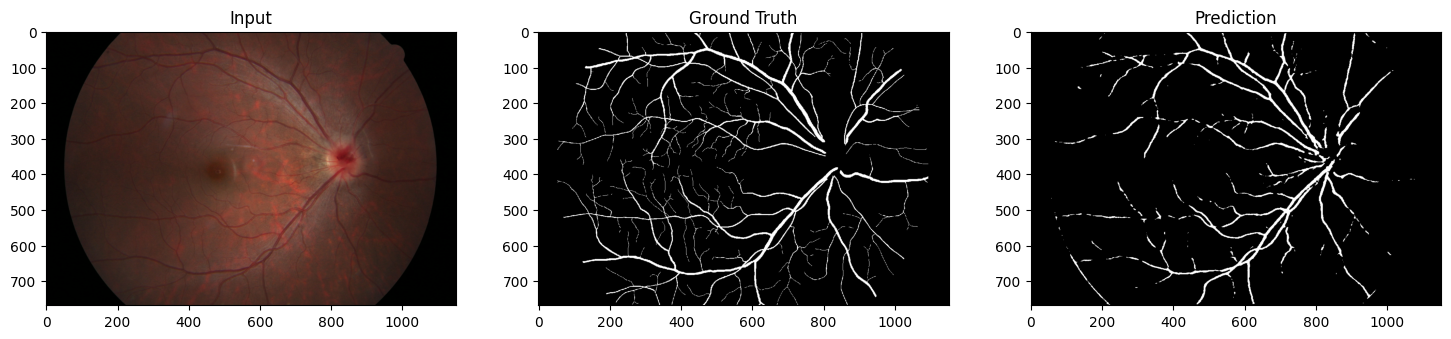

In [18]:
model.load_state_dict(torch.load("baseline_best.pth"))
model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

img = images[0].cpu().permute(1,2,0).numpy()
gt = masks[0].cpu().numpy()
pred = preds[0].cpu().numpy()

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(img)
ax[0].set_title("Input")

ax[1].imshow(gt, cmap='gray')
ax[1].set_title("Ground Truth")

ax[2].imshow(pred, cmap='gray')
ax[2].set_title("Prediction")

plt.show()